# Model Fusion – Combining Structural & Linguistic Experts

**Goal:** Merge the predictions of Model A (structural) and Model B
(linguistic) using a weighted average of their phishing probabilities.

**Approach:**
- Load the pre‑split **test set** for Model A (from `data/model_a/splits/test.csv`)
  and Model B (from `data/model_b/vectorized_data/test.csv`).
- Concatenate the feature columns into a single combined feature matrix.
- Load the saved best models (`best_model_a.joblib`, `best_model_b.joblib`).
- Compute phishing probabilities on the combined test set.
- Try several weight combinations, evaluate each, and select the best.

## 1. Load and Align the Test Splits of Both Models
We load the pre‑saved test sets for Model A (structural features) and Model B
(word‑embedding features). Both datasets come from the same original emails,
so they must have:

- The **same number of rows** (the same subset of emails)
- The **same labels** in the same order

The assertion `assert (test_a["label"].values == test_b["label"].values).all()`
confirms perfect alignment – if it fails, the splits were created with
different random states or a different series of operations and must be
regenerated together.

After the check we separate:
- `y_test` → the true binary labels
- `X_a` → Model A feature matrix (structural properties)
- `X_b` → Model B feature matrix (average Word2Vec vectors)

In [7]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
print("Project root:", PROJECT_ROOT)
test_a = pd.read_csv(PROJECT_ROOT / "data" / "model_a" / "splits" / "test.csv")
test_b = pd.read_csv(PROJECT_ROOT / "data" / "model_b" / "splits" / "word2vec_test.csv")

print("Model A test shape:", test_a.shape)
print("Model B test shape:", test_b.shape)

y_test = test_a["label"].values
X_a = test_a.drop(columns=["label"])
X_b = test_b.drop(columns=["label"])

assert (test_a["label"].values == test_b["label"].values).all(), "Label mismatch – splits are not aligned!"

print("Features A:", X_a.shape)
print("Features B:", X_b.shape)
print("Test label distribution:", pd.Series(y_test).value_counts().to_dict())

Project root: C:\Work\current\phishing_detection
Model A test shape: (32894, 13)
Model B test shape: (32894, 151)
Features A: (32894, 12)
Features B: (32894, 150)
Test label distribution: {1: 17130, 0: 15764}


## 2. Load the Best Models
We load the individually trained `best_model_a.joblib` and `best_model_b.joblib`
from the `models/` folder. Both must support `predict_proba` to return class
probabilities (all our candidates – Logistic Regression, Random Forest,
Naive Bayes – do support this).

In [8]:
import joblib

model_a = joblib.load(PROJECT_ROOT / "models" / "best_model_a.joblib")
model_b = joblib.load(PROJECT_ROOT / "models" / "best_model_b.joblib")

print(f"Model A: {type(model_a).__name__}")
print(f"Model B: {type(model_b).__name__}")

Model A: RandomForestClassifier
Model B: RandomForestClassifier


## 3. Weighted Fusion – Try Multiple Combinations
We define several weight pairs `(w_A, w_B)` such that `w_A + w_B = 1`,
fuse the probabilities:

$$p_{\text{fused}} = w_A \cdot p_A + w_B \cdot p_B$$

and threshold at 0.5 to obtain the final prediction.

We record the **F1 score** for each combination and keep the best.

In [13]:
from sklearn.metrics import f1_score

weights_to_try = {
    "A=0.2 B=0.8": (0.2, 0.8),
    "A=0.3 B=0.7": (0.3, 0.7),
    "A=0.5 B=0.5": (0.5, 0.5),
    "A=0.7 B=0.3": (0.7, 0.3),
    "A=1.0 B=0.0": (1.0, 0.0),
}

best_f1 = 0
best_weights = None
results = []

for label, (w_a, w_b) in weights_to_try.items():
    fused_prob = w_a * p_a + w_b * p_b
    fused_pred = (fused_prob >= 0.5).astype(int)
    f1 = f1_score(y_test, fused_pred)
    results.append({"Weights": label, "F1": f1})
    if f1 > best_f1:
        best_f1 = f1
        best_weights = (w_a, w_b)

results_df = pd.DataFrame(results)
print(results_df.round(4))
print(f"\n- Best F1: {best_f1:.4f} with w_A={best_weights[0]}, w_B={best_weights[1]}")

       Weights      F1
0  A=0.2 B=0.8  0.9885
1  A=0.3 B=0.7  0.9858
2  A=0.5 B=0.5  0.9575
3  A=0.7 B=0.3  0.8844
4  A=1.0 B=0.0  0.8228

- Best F1: 0.9885 with w_A=0.2, w_B=0.8


## 4. Confusion Matrices for Each Weight Combination
Visual comparison of how each fusion scheme behaves on the test set.

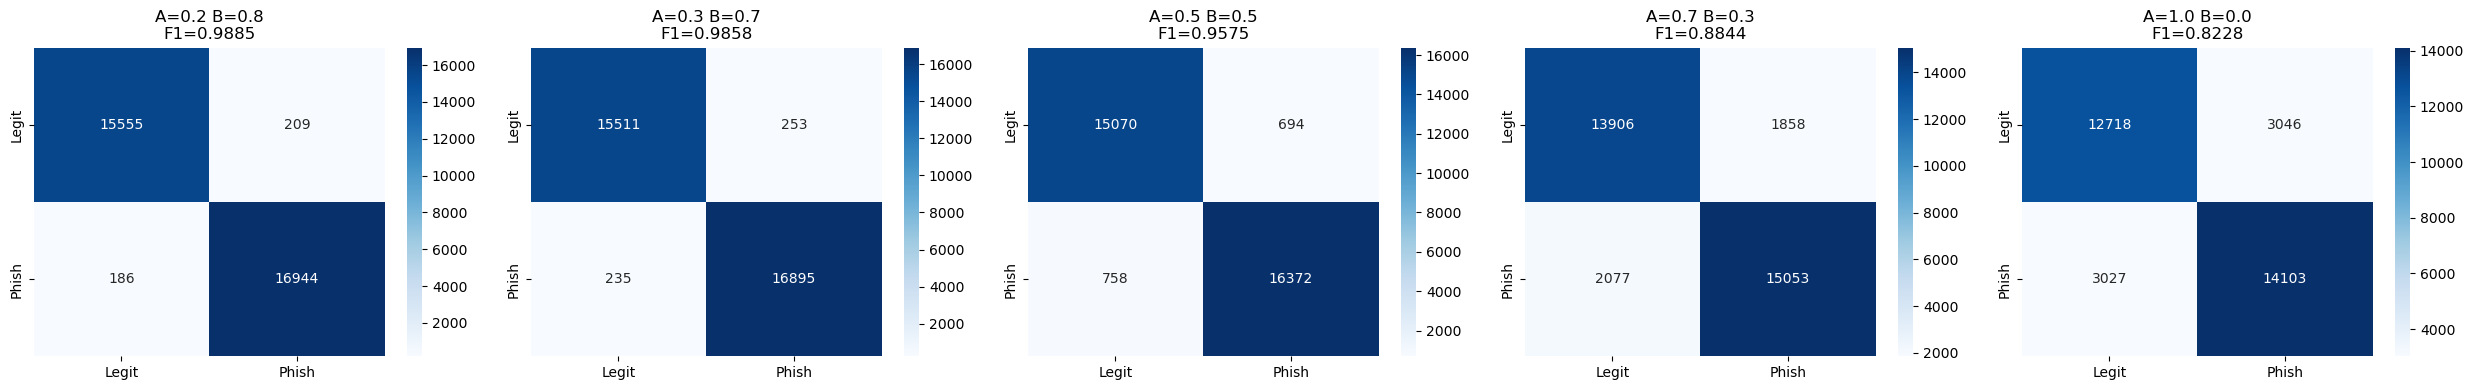

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(25, 4))
axes = axes.flatten()

for i, (w_label, (w_a, w_b)) in enumerate(weights_to_try.items()):
    fused_pred = (w_a * p_a + w_b * p_b >= 0.5).astype(int)
    cm = confusion_matrix(y_test, fused_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Legit", "Phish"],
                yticklabels=["Legit", "Phish"],
                ax=axes[i])
    axes[i].set_title(f"{w_label}\nF1={f1_score(y_test, fused_pred):.4f}")

plt.tight_layout()
plt.show()

## 5. Save the Best Fusion Configuration
Store the optimal weights and threshold for later use (e.g., in a deployment
notebook).

In [15]:
import json

fusion_config = {
    "w_a": best_weights[0],
    "w_b": best_weights[1],
    "threshold": 0.5
}
config_path = PROJECT_ROOT / "models" / "fusion_weights.json"
with open(config_path, "w") as f:
    json.dump(fusion_config, f, indent=2)
print(f"Fusion configuration saved to {config_path}")

Fusion configuration saved to C:\Work\current\phishing_detection\models\fusion_weights.json
